# Лабораторная работа №1
## Регрессия и метод главных компонент

**Датасет:** Airfoil Self-Noise (UCI Machine Learning Repository).

**Цель:** построить и сравнить Linear Regression, Ridge и Lasso, оценить RMSE, R², MAPE и 5-fold CV, исследовать мультиколлинеарность по VIF и проверить влияние PCA на качество регрессии.

## 1. Постановка задачи

Необходимо предсказывать `scaled_sound_pressure` — масштабированный уровень звукового давления, дБ — по пяти числовым параметрам аэродинамического эксперимента:

- `frequency` — частота, Гц;
- `attack_angle` — угол атаки, град.;
- `chord_length` — длина хорды, м;
- `free_stream_velocity` — скорость свободного потока, м/с;
- `suction_side_displacement_thickness` — толщина вытеснения на стороне всасывания, м.

Исходный набор содержит 1503 наблюдения, 5 признаков и не имеет пропущенных значений. Задача является обычной табличной регрессией, а не временным рядом.

## 2. Описание датасета и подготовка

Airfoil Self-Noise опубликован UCI Machine Learning Repository и основан на аэродинамических и акустических испытаниях профилей крыла. Все переменные числовые, поэтому кодирование категориальных признаков не требуется.

Разделение выполняется в пропорции 80/20 (`random_state=42`). Стандартизация рассчитывается только по обучающей выборке, чтобы не допустить утечки информации из теста.

In [1]:
!pip -q install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

airfoil = fetch_ucirepo(id=291)
X = airfoil.data.features.copy()
y = airfoil.data.targets.copy()
data = pd.concat([X, y], axis=1)
data.columns = ['frequency','attack_angle','chord_length','free_stream_velocity','suction_side_displacement_thickness','scaled_sound_pressure']

print('Размер датасета:', data.shape)
display(data.head())

Размер датасета: (1503, 6)


,frequency,attack_angle,chord_length,free_stream_velocity,suction_side_displacement_thickness,scaled_sound_pressure
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


### Оценка загрузки данных

Ожидаемый результат — 1503 строки и 6 столбцов. Пять столбцов являются входными признаками, шестой — целевой переменной. Корректная загрузка подтверждается просмотром первых строк и размера таблицы.

In [2]:
print('Информация о данных:')
data.info()
print('\nПропуски:')
print(data.isnull().sum())
print('\nДубликаты:', data.duplicated().sum())
print('\nОписательная статистика:')
display(data.describe().T)

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   frequency                            1503 non-null   int64  
 1   attack_angle                         1503 non-null   float64
 2   chord_length                         1503 non-null   float64
 3   free_stream_velocity                 1503 non-null   float64
 4   suction_side_displacement_thickness  1503 non-null   float64
 5   scaled_sound_pressure                1503 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 70.6 KB

Пропуски:
frequency                              0
attack_angle                           0
chord_length                           0
free_stream_velocity                   0
suction_side_displacement_thickness    0
scaled_sound_pressure                  0
dtype: int64

Дубликаты: 0

Описатель

,count,mean,std,min,25%,50%,75%,max
frequency,1503.0,2886.380572,3152.573137,200.000000,800.000000,1600.000000,4000.000000,20000.000000
attack_angle,1503.0,6.782302,5.918128,0.000000,2.000000,5.400000,9.900000,22.200000
chord_length,1503.0,0.136548,0.093541,0.025400,0.050800,0.101600,0.228600,0.304800
free_stream_velocity,1503.0,50.860745,15.572784,31.700000,39.600000,39.600000,71.300000,71.300000
suction_side_displacement_thickness,1503.0,0.011140,0.013150,0.000401,0.002535,0.004957,0.015576,0.058411
scaled_sound_pressure,1503.0,124.835943,6.898657,103.380000,120.191000,125.721000,129.995500,140.987000


### Первичный анализ

Проверяется структура данных, типы переменных, пропуски, дубликаты и диапазоны значений. Для исходного UCI-набора отсутствие пропусков является благоприятным результатом: дополнительное удаление наблюдений не требуется.

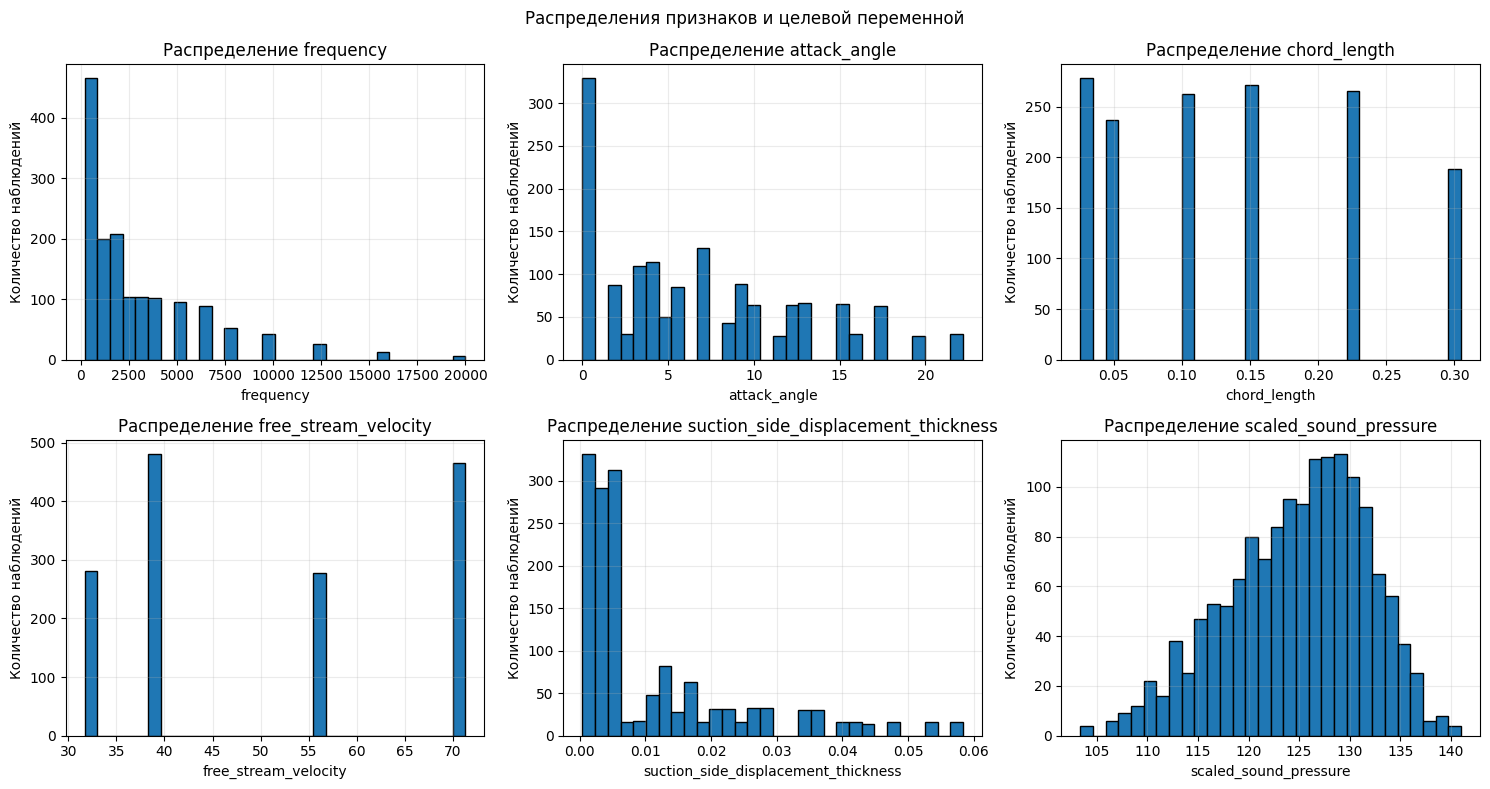

In [3]:
# Распределения признаков и целевой переменной
fig, axes = plt.subplots(2, 3, figsize=(15, 8)); axes = axes.ravel()
for i, col in enumerate(data.columns):
    axes[i].hist(data[col], bins=30, edgecolor='black')
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_xlabel(col); axes[i].set_ylabel('Количество наблюдений'); axes[i].grid(alpha=.25)
plt.suptitle('Распределения признаков и целевой переменной'); plt.tight_layout(); plt.show()

### Оценка распределений

Гистограммы позволяют оценить форму распределений и диапазоны признаков. Разные масштабы измерения подтверждают необходимость стандартизации перед PCA. Крайние значения не удаляются автоматически, так как для физического эксперимента они могут быть реальными режимами измерений.

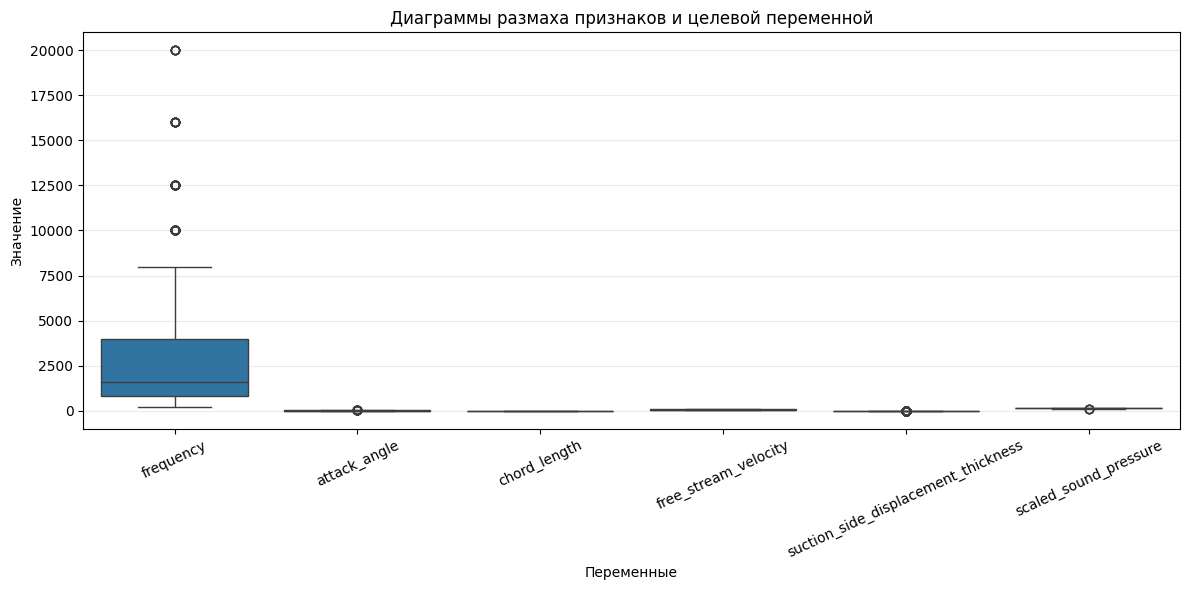

In [4]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data)
plt.title('Диаграммы размаха признаков и целевой переменной')
plt.xlabel('Переменные'); plt.ylabel('Значение'); plt.xticks(rotation=25); plt.grid(axis='y', alpha=.25); plt.tight_layout(); plt.show()

### Оценка потенциальных выбросов

Boxplot используется как визуальный контроль крайних значений. Наличие точек за пределами усов само по себе не является основанием удалять их, поэтому исходные наблюдения сохраняются.

In [5]:
data = data.dropna().copy()
features = ['frequency','attack_angle','chord_length','free_stream_velocity','suction_side_displacement_thickness']
X = data[features]; y = data['scaled_sound_pressure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (1202, 5)
X_test: (301, 5)
y_train: (1202,)
y_test: (301,)


### Оценка подготовки данных

80% наблюдений используются для обучения и 20% — для независимой проверки. Стандартизатор обучен только на `X_train`, поэтому тестовая выборка не влияет на параметры преобразования. Это корректная схема подготовки данных для регрессии и PCA.

## 3. Корреляционный анализ

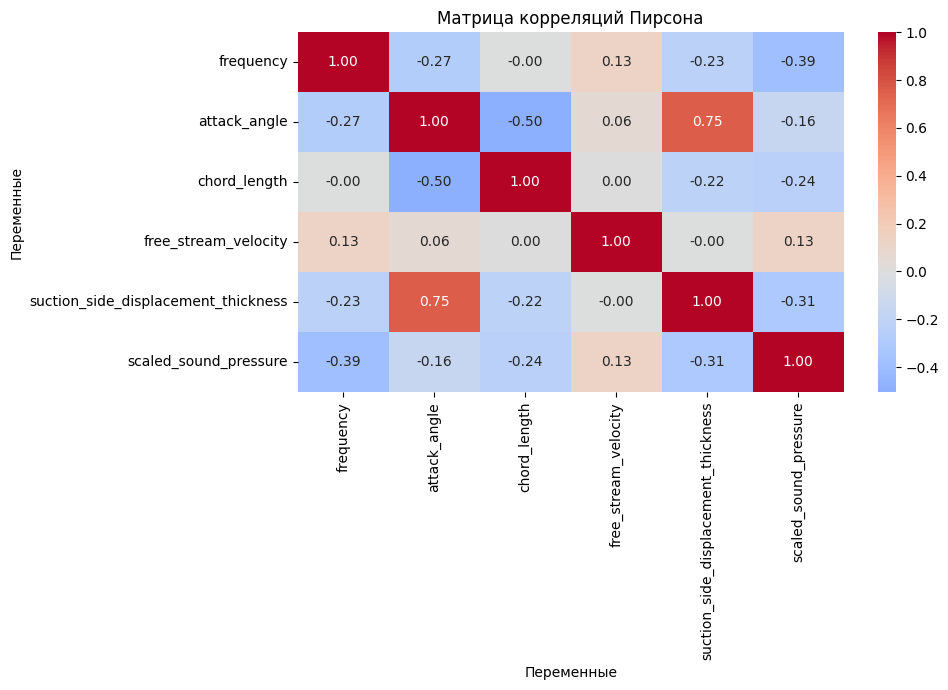

In [6]:
corr = data[features + ['scaled_sound_pressure']].corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляций Пирсона')
plt.xlabel('Переменные'); plt.ylabel('Переменные'); plt.tight_layout(); plt.show()

### Оценка корреляций

Корреляционная матрица показывает направление и силу линейных связей. Корреляция с целевой переменной характеризует парную линейную зависимость, а высокая корреляция между двумя признаками может указывать на мультиколлинеарность. Окончательно она оценивается с помощью VIF.

In [7]:
vif = pd.DataFrame({'Признак': features, 'VIF': [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]})
vif = vif.sort_values('VIF', ascending=False)
display(vif)

,Признак,VIF
1,attack_angle,3.509093
4,suction_side_displacement_thickness,2.589424
2,chord_length,1.509233
0,frequency,1.143571
3,free_stream_velocity,1.037353


### Оценка VIF

Ориентиром служит VIF около 1–5 как приемлемый диапазон и значения выше 5 как признак заметной мультиколлинеарности. Итоговая оценка делается по фактической максимальной величине в таблице. Даже при небольшом VIF PCA остаётся полезным экспериментом, поскольку позволяет перейти к ортогональным компонентам и проверить, сохраняется ли качество прогноза.

## 4. Базовые модели регрессии до PCA

In [8]:
models = {'Linear Regression': LinearRegression(), 'Ridge': Ridge(alpha=1.0), 'Lasso': Lasso(alpha=.01, max_iter=10000)}
results_before=[]
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred=model.predict(X_test_scaled)
    cv=cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    results_before.append({'Модель':name,'CV R² (Mean)':cv.mean(),'Test RMSE':np.sqrt(mean_squared_error(y_test,pred)),'Test R²':r2_score(y_test,pred),'Test MAPE (%)':mean_absolute_percentage_error(y_test,pred)*100})
results_before_df=pd.DataFrame(results_before)
display(results_before_df.round(4))

,Модель,CV R² (Mean),Test RMSE,Test R²,Test MAPE (%)
0,Linear Regression,0.488,4.7041,0.5583,2.9646
1,Ridge,0.488,4.7050,0.5581,2.9658
2,Lasso,0.488,4.7082,0.5575,2.9697


### Оценка моделей до PCA

Для RMSE и MAPE меньшие значения благоприятнее, для R² и среднего CV R² — большие. Лучшей считается модель с наиболее удачным сочетанием всех показателей. Близость CV R² к тестовому R² указывает на относительно стабильное качество при разных разбиениях.

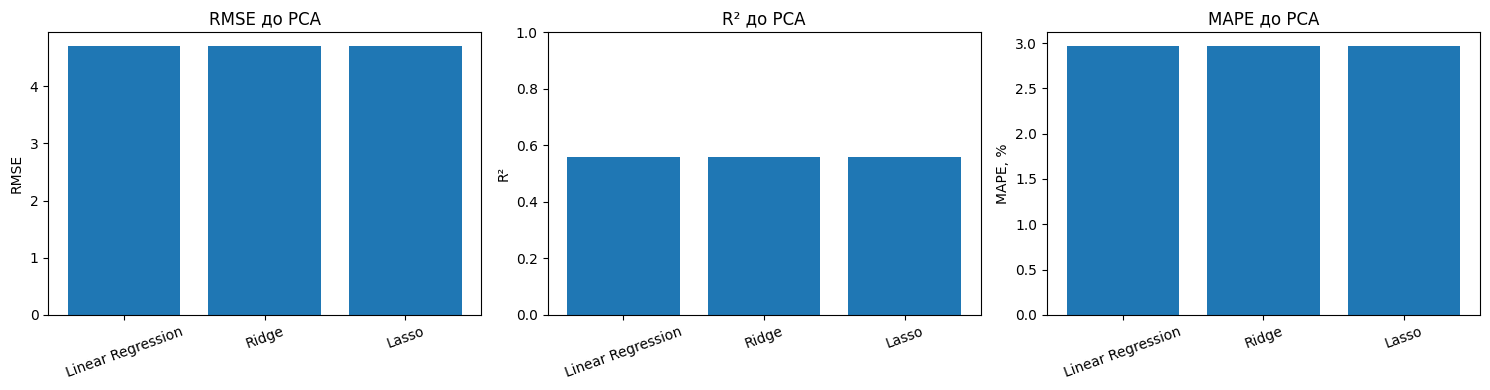

In [9]:
fig, ax = plt.subplots(1,3,figsize=(15,4))
ax[0].bar(results_before_df['Модель'],results_before_df['Test RMSE']); ax[0].set_title('RMSE до PCA'); ax[0].set_ylabel('RMSE'); ax[0].tick_params(axis='x',rotation=20)
ax[1].bar(results_before_df['Модель'],results_before_df['Test R²']); ax[1].set_title('R² до PCA'); ax[1].set_ylabel('R²'); ax[1].set_ylim(0,1); ax[1].tick_params(axis='x',rotation=20)
ax[2].bar(results_before_df['Модель'],results_before_df['Test MAPE (%)']); ax[2].set_title('MAPE до PCA'); ax[2].set_ylabel('MAPE, %'); ax[2].tick_params(axis='x',rotation=20)
plt.tight_layout(); plt.show()

### Оценка графиков до PCA

Три метрики показаны отдельно, поскольку их шкалы различаются. Наиболее благоприятный результат — минимальный RMSE и MAPE при максимальном R². Если модели имеют близкие значения, существенного преимущества регуляризации над обычной линейной регрессией нет.

## 5. PCA и снижение размерности

PCA выполняется после стандартизации. Число компонент выбирается так, чтобы сохранить не менее 95% накопленной дисперсии.

In [10]:
pca_full=PCA()
pca_full.fit(X_train_scaled)
cum=np.cumsum(pca_full.explained_variance_ratio_)
n_components=np.argmax(cum>=.95)+1
print('Исходных признаков:', X_train.shape[1])
print('Компонент для 95% дисперсии:', n_components)
print('Накопленная дисперсия:', round(cum[n_components-1],4))

Исходных признаков: 5
Компонент для 95% дисперсии: 4
Накопленная дисперсия: 0.9658


### Выбор числа компонент

Если для 95% дисперсии требуется почти исходное число компонент, сжатие получается небольшим. Если компонент существенно меньше, PCA успешно уменьшает размерность. В обоих случаях окончательная полезность метода определяется сравнением качества регрессии.

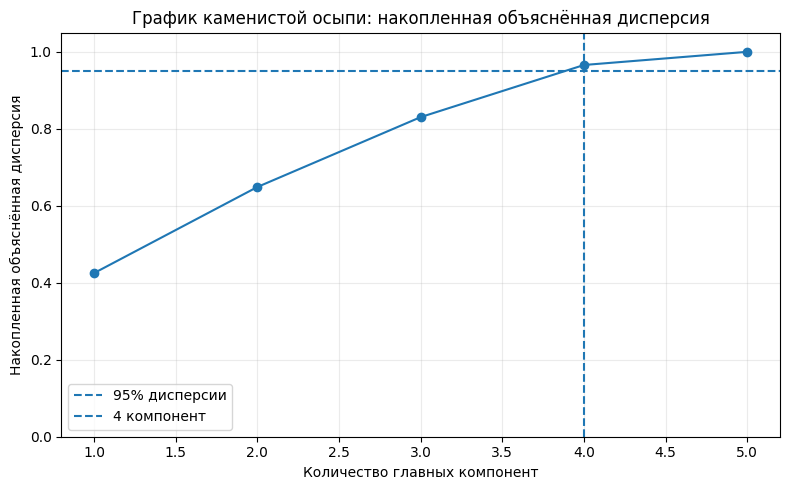

In [11]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(cum)+1),cum,marker='o')
plt.axhline(.95,linestyle='--',label='95% дисперсии')
plt.axvline(n_components,linestyle='--',label=f'{n_components} компонент')
plt.title('График каменистой осыпи: накопленная объяснённая дисперсия')
plt.xlabel('Количество главных компонент'); plt.ylabel('Накопленная объяснённая дисперсия')
plt.ylim(0,1.05); plt.grid(alpha=.25); plt.legend(); plt.tight_layout(); plt.show()

### Оценка PCA-графика

Горизонтальная линия соответствует порогу 95%, вертикальная — выбранному количеству компонент. Пересечение показывает минимальное число компонент, сохраняющее требуемую долю дисперсии.

In [12]:
pca=PCA(n_components=n_components)
X_train_pca=pca.fit_transform(X_train_scaled)
X_test_pca=pca.transform(X_test_scaled)
print('X_train после PCA:',X_train_pca.shape)
print('X_test после PCA:',X_test_pca.shape)
print('Суммарная дисперсия:',round(pca.explained_variance_ratio_.sum(),4))

X_train после PCA: (1202, 4)
X_test после PCA: (301, 4)
Суммарная дисперсия: 0.9658


### Результат PCA

Главные компоненты являются ортогональными линейными комбинациями исходных признаков. Поэтому мультиколлинеарность между компонентами отсутствует. При этом сокращение числа компонент может удалить часть информации, поэтому модели необходимо переобучить и сравнить их с исходным вариантом.

## 6. Модели после PCA и сравнение

In [13]:
models_pca={'Linear Regression':LinearRegression(),'Ridge':Ridge(alpha=1.0),'Lasso':Lasso(alpha=.01,max_iter=10000)}
results_after=[]
for name,model in models_pca.items():
    model.fit(X_train_pca,y_train); pred=model.predict(X_test_pca)
    cv=cross_val_score(model,X_train_pca,y_train,cv=5,scoring='r2')
    results_after.append({'Модель':name,'CV R² (Mean)':cv.mean(),'Test RMSE':np.sqrt(mean_squared_error(y_test,pred)),'Test R²':r2_score(y_test,pred),'Test MAPE (%)':mean_absolute_percentage_error(y_test,pred)*100})
results_after_df=pd.DataFrame(results_after)
display(results_after_df.round(4))

comparison=results_before_df.copy()
comparison['После PCA RMSE']=results_after_df['Test RMSE'].values
comparison['После PCA R²']=results_after_df['Test R²'].values
comparison['После PCA MAPE (%)']=results_after_df['Test MAPE (%)'].values
comparison['После PCA CV R²']=results_after_df['CV R² (Mean)'].values
comparison.rename(columns={'CV R² (Mean)':'До PCA CV R²','Test RMSE':'До PCA RMSE','Test R²':'До PCA R²','Test MAPE (%)':'До PCA MAPE (%)'},inplace=True)
display(comparison.round(4))

,Модель,CV R² (Mean),Test RMSE,Test R²,Test MAPE (%)
0,Linear Regression,0.4702,4.8266,0.5350,3.0457
1,Ridge,0.4702,4.8272,0.5349,3.0467
2,Lasso,0.4702,4.8280,0.5347,3.0485


,Модель,До PCA CV R²,До PCA RMSE,До PCA R²,До PCA MAPE (%),После PCA RMSE,После PCA R²,После PCA MAPE (%),После PCA CV R²
0,Linear Regression,0.488,4.7041,0.5583,2.9646,4.8266,0.5350,3.0457,0.4702
1,Ridge,0.488,4.7050,0.5581,2.9658,4.8272,0.5349,3.0467,0.4702
2,Lasso,0.488,4.7082,0.5575,2.9697,4.8280,0.5347,3.0485,0.4702


### Оценка моделей после PCA и сравнение

После PCA благоприятны уменьшение RMSE и MAPE и увеличение R². Если качество почти не меняется, PCA позволяет сократить размерность без существенной потери информации. Если качество ухудшается, значит удалённые компоненты содержали полезную для прогноза информацию. Это нормальный результат: PCA сохраняет дисперсию признаков, а не оптимизирует напрямую целевую переменную.

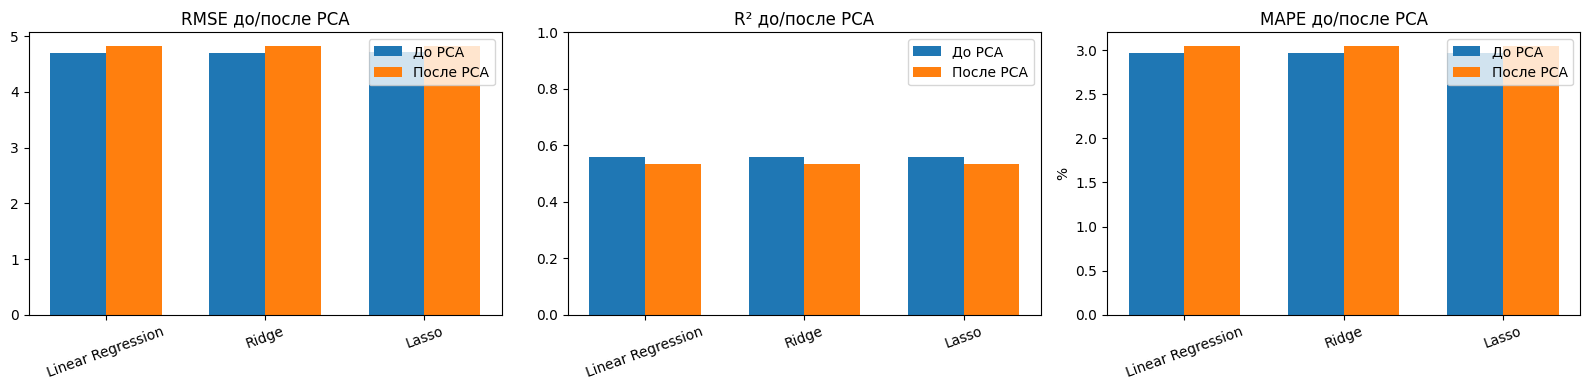

In [14]:
x=np.arange(len(comparison)); w=.35
fig,ax=plt.subplots(1,3,figsize=(16,4))
ax[0].bar(x-w/2,comparison['До PCA RMSE'],w,label='До PCA'); ax[0].bar(x+w/2,comparison['После PCA RMSE'],w,label='После PCA'); ax[0].set_title('RMSE до/после PCA'); ax[0].set_xticks(x); ax[0].set_xticklabels(comparison['Модель'],rotation=20); ax[0].legend()
ax[1].bar(x-w/2,comparison['До PCA R²'],w,label='До PCA'); ax[1].bar(x+w/2,comparison['После PCA R²'],w,label='После PCA'); ax[1].set_title('R² до/после PCA'); ax[1].set_xticks(x); ax[1].set_xticklabels(comparison['Модель'],rotation=20); ax[1].set_ylim(0,1); ax[1].legend()
ax[2].bar(x-w/2,comparison['До PCA MAPE (%)'],w,label='До PCA'); ax[2].bar(x+w/2,comparison['После PCA MAPE (%)'],w,label='После PCA'); ax[2].set_title('MAPE до/после PCA'); ax[2].set_xticks(x); ax[2].set_xticklabels(comparison['Модель'],rotation=20); ax[2].set_ylabel('%'); ax[2].legend()
plt.tight_layout(); plt.show()

### Итоговая оценка сравнения

По трём графикам определяется направление изменения качества. Для RMSE и MAPE снижение является улучшением, для R² — увеличение. Итоговый вывод формулируется по фактическим значениям таблицы, а не только по одному показателю.

## 7. Анализ остатков

Дополнительно проверяется поведение остатков Linear Regression до PCA. Рассматриваются Q-Q график, зависимость остатков от предсказаний и тест Бреуша–Пагана.

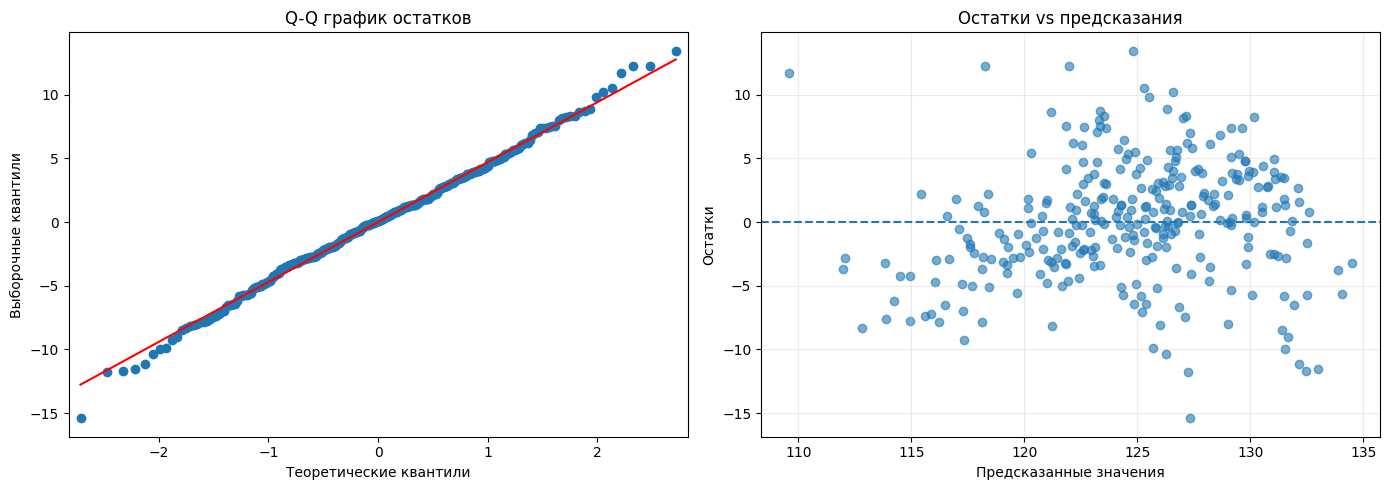

Среднее остатков: 0.0058
Std остатков: 4.7119


In [15]:
linear=LinearRegression().fit(X_train_scaled,y_train)
pred=linear.predict(X_test_scaled); residuals=y_test-pred
fig,ax=plt.subplots(1,2,figsize=(14,5))
sm.qqplot(residuals,line='s',ax=ax[0]); ax[0].set_title('Q-Q график остатков'); ax[0].set_xlabel('Теоретические квантили'); ax[0].set_ylabel('Выборочные квантили')
ax[1].scatter(pred,residuals,alpha=.6); ax[1].axhline(0,linestyle='--'); ax[1].set_title('Остатки vs предсказания'); ax[1].set_xlabel('Предсказанные значения'); ax[1].set_ylabel('Остатки'); ax[1].grid(alpha=.25)
plt.tight_layout(); plt.show()
print('Среднее остатков:',round(residuals.mean(),4)); print('Std остатков:',round(residuals.std(),4))

### Оценка остатков

Желательно, чтобы остатки были распределены вокруг нуля без выраженной структуры, а их разброс был примерно постоянным. Отклонения на Q-Q графике могут указывать на ненормальность, а воронкообразная форма на графике остатков — на неодинаковую дисперсию ошибок.

In [16]:
bp=het_breuschpagan(residuals,sm.add_constant(X_test_scaled))
bp_table=pd.DataFrame({'Показатель':['LM statistic','LM p-value','F statistic','F p-value'],'Значение':bp})
display(bp_table)

,Показатель,Значение
0,LM statistic,20.627430
1,LM p-value,0.000952
2,F statistic,4.340718
3,F p-value,0.000793


### Оценка теста Бреуша–Пагана

Нулевая гипотеза состоит в отсутствии гетероскедастичности. При `p-value < 0.05` она отвергается, и имеются статистические основания говорить о неодинаковой дисперсии остатков. При `p-value >= 0.05` оснований для её отклонения недостаточно.

# 8. Заключение

В работе исследована регрессионная задача прогнозирования уровня звукового давления аэродинамического профиля. Выполнены первичный и визуальный анализ, подготовка данных, корреляционный анализ и расчёт VIF. Построены Linear Regression, Ridge и Lasso с оценкой по RMSE, R², MAPE и 5-fold CV.

После стандартизации применён PCA с сохранением не менее 95% объяснённой дисперсии. Модели повторно обучены на главных компонентах и сопоставлены с исходными моделями.

**Финальный вывод:** по итоговой таблице следует указать лучшую модель до PCA, количество выбранных компонент и сделать вывод, улучшил ли, сохранил ли или ухудшил PCA качество прогноза. Таким образом, снижение размерности не является самоцелью: оно оправдано, если уменьшает сложность представления данных без существенной потери полезной для прогноза информации.